In [1]:
import pandas as pd

In [2]:
pizza_path="/content/drive/MyDrive/pizza_not_pizza"

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
!pip install split-folders

In [5]:
import splitfolders
splitfolders.ratio("/content/drive/MyDrive/pizza_not_pizza", ratio=(0.7, 0.2, 0.1), output="pizza_no_pizza")

Copying files: 1984 files [00:35, 55.80 files/s] 


In [26]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/pizza_no_pizza/train",
    image_size= (128,128),
    batch_size=64,
    subset = "training",
    seed = 42,
    validation_split=0.2



)

Found 1388 files belonging to 2 classes.
Using 1111 files for training.


In [27]:
test_data= tf.keras.utils.image_dataset_from_directory(
    "/content/pizza_no_pizza/test",
    image_size= (128,128),
    batch_size=64,
    subset = "validation",
    seed = 42,
    validation_split=0.2



)

Found 200 files belonging to 2 classes.
Using 40 files for validation.


In [28]:
val_data= tf.keras.utils.image_dataset_from_directory(
    "/content/pizza_no_pizza/val",
    image_size= (128,128),
    batch_size=64,
    subset = "validation",
    seed = 42,
    validation_split=0.2



)

Found 396 files belonging to 2 classes.
Using 79 files for validation.


In [29]:
import cv2
from PIL import Image
from IPython.display import display

array([[[10, 15, 54],
        [11, 16, 55],
        [12, 16, 57],
        ...,
        [75, 47, 53],
        [63, 35, 41],
        [61, 33, 39]],

       [[10, 15, 54],
        [11, 16, 55],
        [12, 16, 57],
        ...,
        [87, 59, 65],
        [69, 41, 47],
        [61, 33, 39]],

       [[11, 15, 56],
        [12, 16, 57],
        [13, 17, 58],
        ...,
        [96, 70, 76],
        [86, 58, 64],
        [80, 52, 58]],

       ...,

       [[21, 22, 72],
        [21, 22, 72],
        [21, 22, 73],
        ...,
        [11, 11, 35],
        [12, 13, 34],
        [12, 13, 34]],

       [[22, 20, 72],
        [22, 20, 72],
        [20, 21, 72],
        ...,
        [10, 11, 32],
        [10, 11, 32],
        [10, 11, 32]],

       [[21, 19, 71],
        [21, 19, 71],
        [19, 20, 71],
        ...,
        [ 9, 10, 31],
        [ 8,  9, 30],
        [ 8,  9, 30]]], dtype=uint8)
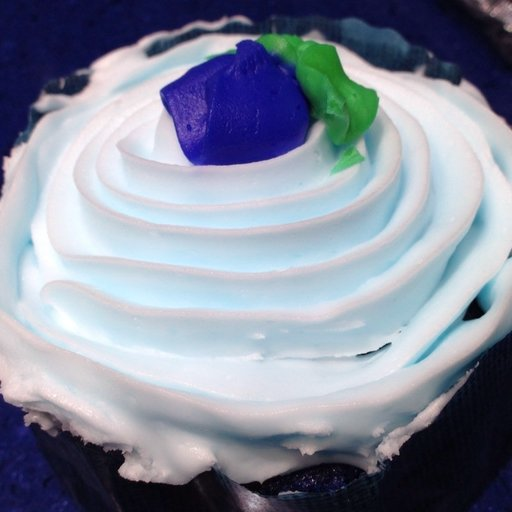

In [30]:
cv2.imread("/content/drive/MyDrive/pizza_not_pizza/not_pizza/1012312.jpg")

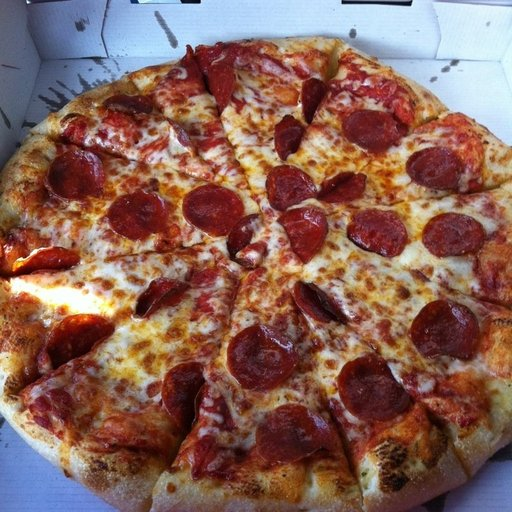

In [31]:
display(Image.open("/content/drive/MyDrive/pizza_not_pizza/pizza/1001116.jpg"))

In [35]:
model=keras.Sequential([
    layers.Conv2D(64, (3, 3), padding="same", activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128,(3,3),padding="same", activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [37]:
model.fit(train_data,epochs=10,validation_data=val_data)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.4905 - loss: 347.6628 - val_accuracy: 0.4937 - val_loss: 0.6996
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.6373 - loss: 0.6787 - val_accuracy: 0.4937 - val_loss: 0.7008
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7570 - loss: 0.5613 - val_accuracy: 0.6076 - val_loss: 0.6965
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.8425 - loss: 0.3579 - val_accuracy: 0.5696 - val_loss: 0.8314
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9334 - loss: 0.1942 - val_accuracy: 0.6076 - val_loss: 1.1601
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9757 - loss: 0.0935 - val_accuracy: 0.5696 - val_loss: 1.4924
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9919 - loss: 0.0357 - val_accuracy: 0.5823 - val_loss: 1.8889
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9973 - loss: 0.0140 - val_accuracy: 0.594